In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Breast_cancer_data.csv')

In [3]:
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [4]:
df.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [8]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


In [9]:
import plotly.express as px

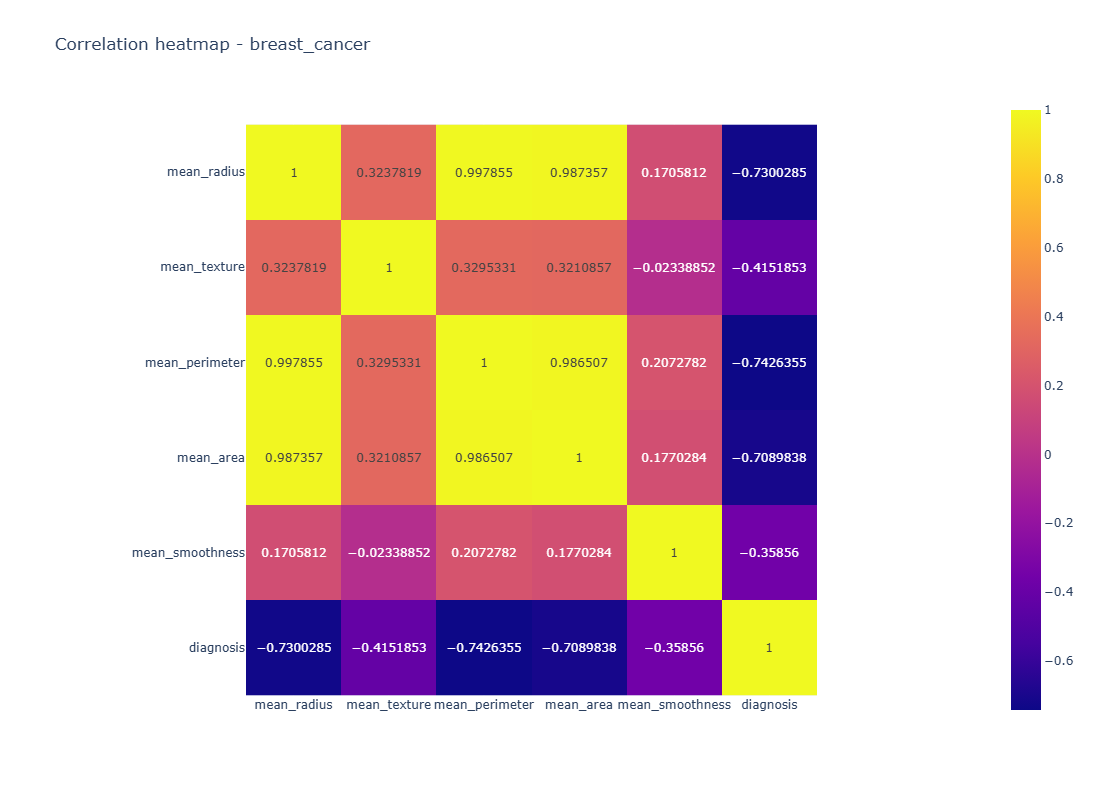

In [11]:
corre = df.corr(numeric_only=True)
fig = px.imshow(corre,text_auto = True, title = "Correlation heatmap - breast_cancer")
fig.update_layout(
    width = 800,
    height = 800
)
fig.show()

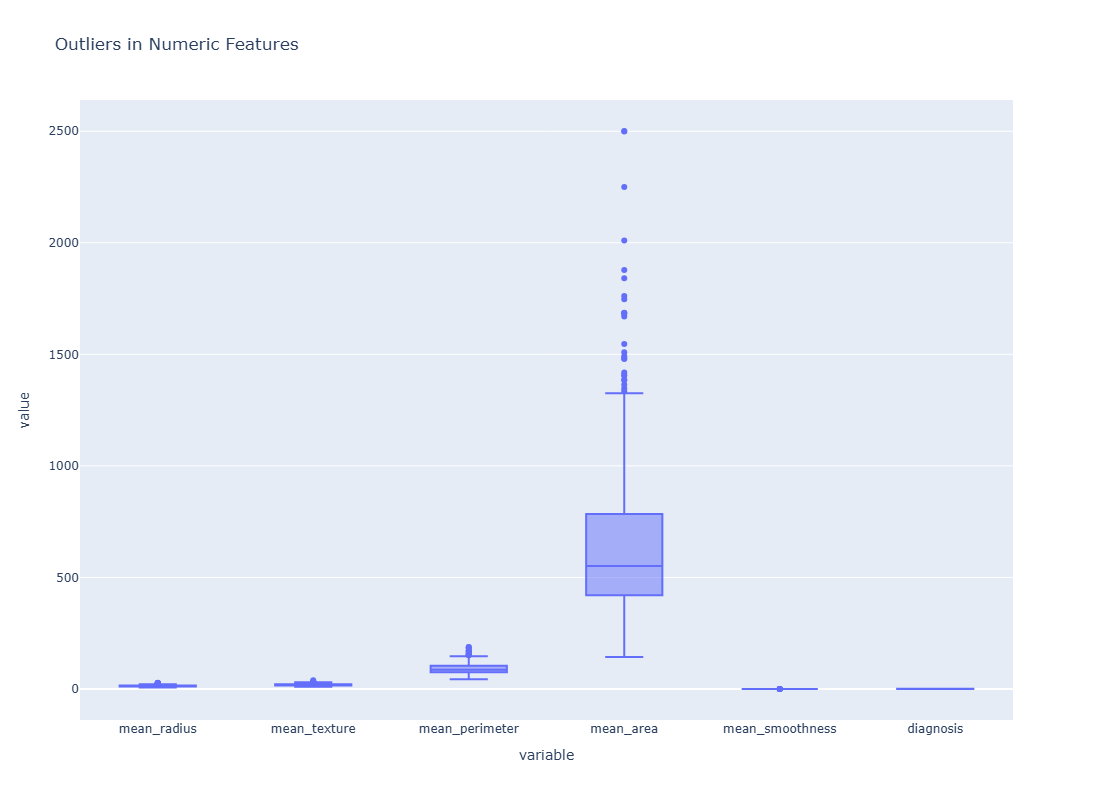

In [17]:
fig = px.box(df.melt(),x ="variable",y ="value",title="Outliers in Numeric Features")
fig.update_layout( width = 800, height = 800)
fig.show()

In [18]:
for col in df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

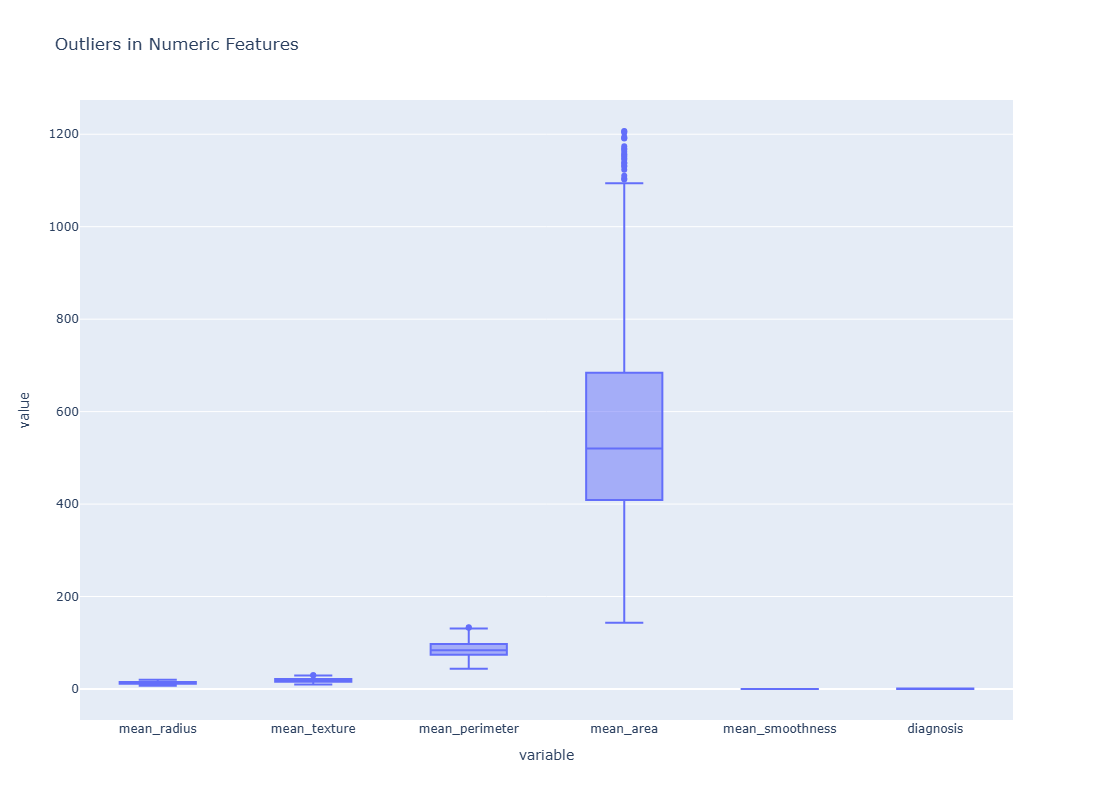

In [19]:
fig = px.box(df.melt(),x ="variable",y ="value",title="Outliers in Numeric Features")
fig.update_layout( width = 800, height = 800)
fig.show()

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [42]:
X = df.drop('diagnosis',axis = 1)
y = df['diagnosis']

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1,stratify = y,random_state = 42)

In [44]:
X_train.shape

(456, 5)

In [45]:
y_train.shape

(456,)

In [47]:
se = StandardScaler()
X_train_scaled = se.fit_transform(X_train)
X_test_scaled = se.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [32]:
X_train.shape

(456, 5)

In [48]:
from sklearn.neighbors import KNeighborsClassifier

In [49]:
model = KNeighborsClassifier(n_neighbors= 3)

In [50]:
model.fit(X_train_scaled,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [51]:
y_pred = model.predict(X_test_scaled)

In [52]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [53]:
accuracy_score(y_test,y_pred)

0.9607843137254902

In [54]:
confusion_matrix(y_test,y_pred)

array([[14,  2],
       [ 0, 35]])

In [55]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      0.88      0.93        16\n           1       0.95      1.00      0.97        35\n\n    accuracy                           0.96        51\n   macro avg       0.97      0.94      0.95        51\nweighted avg       0.96      0.96      0.96        51\n'

In [57]:
import joblib

joblib.dump(model,'model.pkl')
joblib.dump(se,'scaler.pkl')

['scaler.pkl']